In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

url = 'https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/polar_cube_datasets/ice_velocity/ice_velocity.zarr/'

In [2]:
ds = xr.open_zarr(url, chunks={"time": 1})

/tmp/ipykernel_17252/750069727.py:1: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_zarr(url, chunks={"time": 1})


In [4]:
# select 2 dates, 6 months apart
t0 = "2019-01-01"
t1 = (xr.DataArray(np.datetime64(t0)).dt.floor("D") + np.timedelta64(183, "D")).values

ds0 = ds.sel(time=t0, method="nearest")
ds1 = ds.sel(time=t1, method="nearest")

ds0.time.values, ds1.time.values

(np.datetime64('2019-01-01T00:00:00.000000000'),
 np.datetime64('2019-07-01T00:00:00.000000000'))

In [5]:
# select variables
vx_name = "land_ice_surface_easting_velocity"
vy_name = "land_ice_surface_northing_velocity"
vv_name = "land_ice_surface_velocity_magnitude"

vx0, vy0, vv0 = ds0[vx_name], ds0[vy_name], ds0[vv_name]
vx1, vy1, vv1 = ds1[vx_name], ds1[vy_name], ds1[vv_name]

In [6]:
# sample values for faster plotting, do not interpolate 
step = 500

x = ds.x.isel(x=slice(None, None, step))
y = ds.y.isel(y=slice(None, None, step))

vx0c = vx0.isel(x=slice(None, None, step), y=slice(None, None, step))
vy0c = vy0.isel(x=slice(None, None, step), y=slice(None, None, step))
vv0c = vv0.isel(x=slice(None, None, step), y=slice(None, None, step))

vx1c = vx1.isel(x=slice(None, None, step), y=slice(None, None, step))
vy1c = vy1.isel(x=slice(None, None, step), y=slice(None, None, step))
vv1c = vv1.isel(x=slice(None, None, step), y=slice(None, None, step))

In [ ]:
# calculate the values
vx0c = vx0c.load()
vy0c = vy0c.load()
vv0c = vv0c.load()

vx1c = vx1c.load()
vy1c = vy1c.load()
vv1c = vv1c.load()

X, Y = np.meshgrid(x.values, y.values)

speed = xr.concat([vv0c, vv1c], dim="plot_time").values
finite_speed = speed[np.isfinite(speed)]

vmin = np.nanpercentile(finite_speed, 2)
vmax = np.nanpercentile(finite_speed, 98)

In [ ]:
# use calving fronts as antarctica background
import geopandas as gpd
bucket = 's3://EarthCODE/'
endpoint_url = "https://s3.waw4-1.cloudferro.com"
region_name = "eu-west-2"
file = 'OSCAssets/polar_cube_datasets/calving_fronts/Antarctic_coastlines.parquet'


gdf = gpd.read_parquet(
    f"{bucket}{file}",
    storage_options={ "anon": True, 
                    "client_kwargs": {
                        "endpoint_url": endpoint_url,
                        "region_name": region_name
                    }
    }
)

gdf['area'] = gdf.area
largest_polygon = gdf.sort_values('area', ascending=False).iloc[[0]]

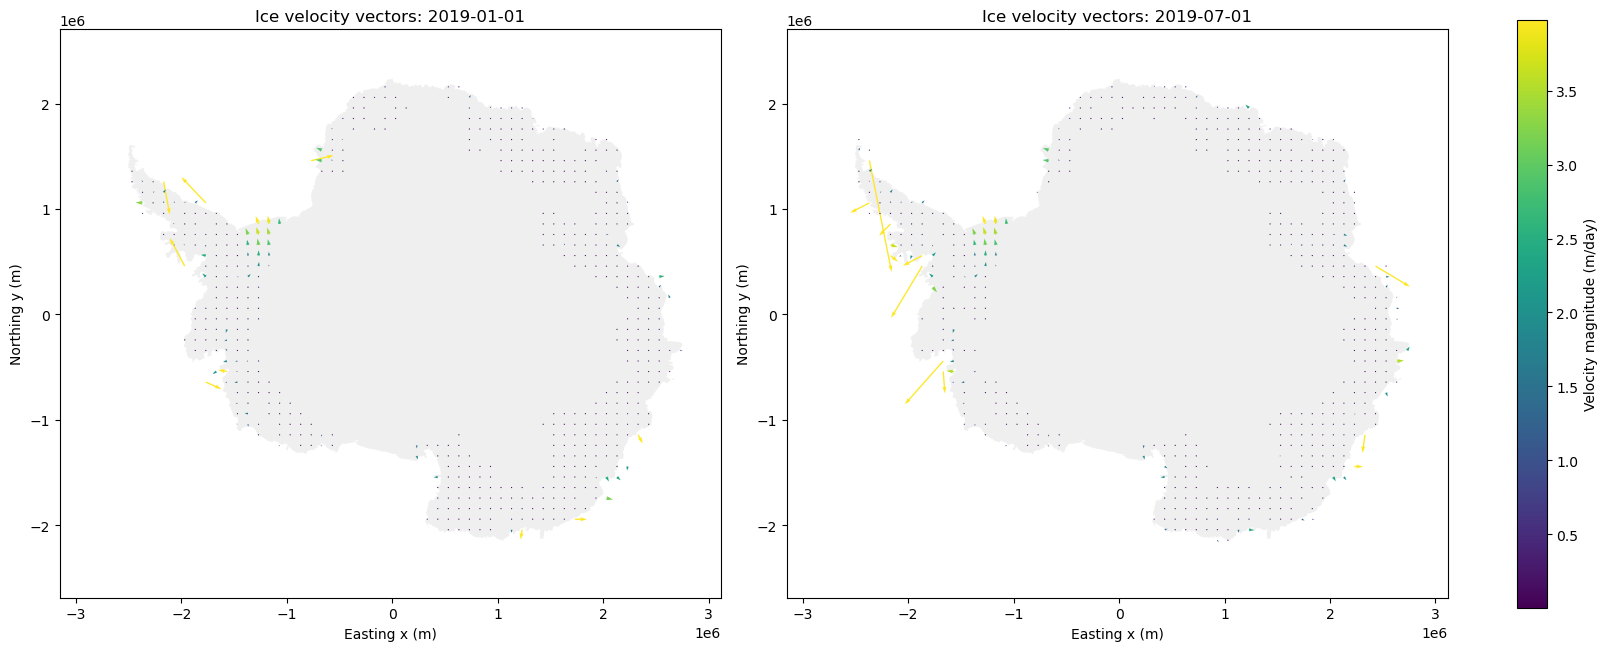

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)
# plot calving fronts as background
largest_polygon.plot(ax=axes[0], color='grey', alpha=.12)
largest_polygon.plot(ax=axes[1], color='grey', alpha=.12)


q0 = axes[0].quiver(
    X, Y,
    vx0c.values, vy0c.values,
    vv0c.values,
    cmap="viridis",
    clim=(vmin, vmax),
    angles="xy",
    scale_units="xy",
    scale=0.00005,
    width=0.002
)
axes[0].set_aspect("equal")
axes[0].set_title(f"Ice velocity vectors: {np.datetime_as_string(ds0.time.values, unit='D')}")
axes[0].set_xlabel("Easting x (m)")
axes[0].set_ylabel("Northing y (m)")


q1 = axes[1].quiver(
    X, Y,
    vx1c.values, vy1c.values,
    vv1c.values,
    cmap="viridis",
    clim=(vmin, vmax),
    angles="xy",
    scale_units="xy",
    scale=0.00005,
    width=0.002
)
axes[1].set_aspect("equal")
axes[1].set_title(f"Ice velocity vectors: {np.datetime_as_string(ds1.time.values, unit='D')}")
axes[1].set_xlabel("Easting x (m)")
axes[1].set_ylabel("Northing y (m)")

fig.colorbar(q1, ax=axes, label="Velocity magnitude (m/day)", shrink=0.85)

plt.show()